# Dataset description 

## Overview:
This dataset is designed for phishing email detection using machine learning. It combines:

-   ~500,000 non-phishing ("safe") emails from the Enron Email Dataset
-   ~20,000 phishing and safe emails from the Phishing Email Dataset
-   Every email was cleaned and passed through a custom NLP feature extraction pipeline that focuses on phishing indicators. The goal is to provide a ready-to-use dataset for classification tasks with minimal preprocessing.

## Column Details
-   num_words - Total number of words in the email body
-   num_unique_words- Count of unique words used
-   num_stopwords - Count of common stopwords (e.g., "the", "and", "in")
-   num_links - Number of hyperlinks detected
-   num_unique_domains - Number of unique domains in links (e.g., "paypal.com")
-   num_email_addresses - Count of email addresses found in the text
-   num_spelling_errors - Count of misspelled words
-   num_urgent_keywords - Number of urgent words (e.g., "urgent", "verify", "update")
-   label - Target variable: 0 = Safe Email, 1 = Phishing Email

## Notes:

This dataset does not contain raw text or headers, only engineered features for training/testing models.
Spell checking used pyspellchecker on filtered tokens.
Stopwords were a fixed English list.
No personal or PII information is included.

### Original Data
[https://www.kaggle.com/datasets/ethancratchley/email-phishing-dataset?resource=download]

# Import libs

In [1]:
import pandas as pd
import numpy as np

# Load data

In [6]:
df = pd.read_csv('email_phishing_data.csv')
df.head(3)

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0


# Data Exploration

-   Data types e shape

In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB


-   Distribuzione delle etichette (phishing vs legittime):

<Axes: xlabel='label'>

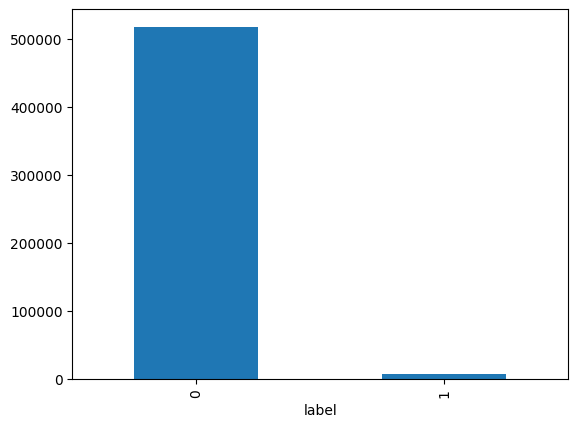

In [7]:
df['label'].value_counts().plot(kind='bar')

-   Controllo valori nulli:

In [8]:
df.isnull().sum()

num_words              0
num_unique_words       0
num_stopwords          0
num_links              0
num_unique_domains     0
num_email_addresses    0
num_spelling_errors    0
num_urgent_keywords    0
label                  0
dtype: int64

# Mod 1: Logistic regression

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Supponiamo tu abbia un DataFrame df con 'label' come target
X = df.drop(columns='label')
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modello
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predizioni
y_pred = logreg.predict(X_test)

# Valutazione
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Logistic Regression ===
[[103573      0]
 [  1395      2]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    103573
           1       1.00      0.00      0.00      1397

    accuracy                           0.99    104970
   macro avg       0.99      0.50      0.50    104970
weighted avg       0.99      0.99      0.98    104970




La matrice di confusione riporta i conteggi delle predizioni fatte dal modello rispetto ai valori reali:

- **[0,0] = True Negatives (TN)**: istanze di classe 0 correttamente classificate.
- **[0,1] = False Positives (FP)**: istanze di classe 0 erroneamente classificate come classe 1.
- **[1,0] = False Negatives (FN)**: istanze di classe 1 erroneamente classificate come classe 0.
- **[1,1] = True Positives (TP)**: istanze di classe 1 correttamente classificate.

---

### 📈 Classification Report

| Classe | Precision | Recall | F1-score | Support |
|--------|-----------|--------|----------|---------|

#### Precision
- Formula: `TP / (TP + FP)`
- Misura la proporzione di predizioni corrette tra quelle fatte per la classe positiva.
- Indica l'accuratezza tra le predizioni della classe.

#### Recall (Sensibilità)
- Formula: `TP / (TP + FN)`
- Misura la proporzione di veri positivi identificati sul totale degli esempi realmente positivi.
- Indica la copertura della classe.

#### F1-score
- Formula: `2 * (Precision * Recall) / (Precision + Recall)`
- Media armonica tra precision e recall.
- Equilibrio tra accuratezza e copertura.

#### Support
- Numero di istanze reali appartenenti a ciascuna classe nel set di test.

---

### 🎯 Accuracy
- Formula: `(TP + TN) / Totale`
- Percentuale di predizioni corrette su tutte le istanze.

---

### ⚖️ Macro Average
- Media semplice delle metriche calcolate su ogni classe.
- Formula (es. recall macro): `(recall_0 + recall_1) / 2`

---

### 📦 Weighted Average
- Media pesata delle metriche in base al numero di esempi per classe.
- Formula (es. precision weighted): `(precision_0 * support_0 + precision_1 * support_1) / totale`


# Mod 2: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Stesso split già fatto sopra (puoi riutilizzarlo)

# Modello
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predizioni
y_pred_rf = rf.predict(X_test)

# Valutazione
print("=== Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
[[103505     68]
 [  1006    391]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    103573
           1       0.85      0.28      0.42      1397

    accuracy                           0.99    104970
   macro avg       0.92      0.64      0.71    104970
weighted avg       0.99      0.99      0.99    104970



## 🔍 ROC Curve – Cos'è, Come si Calcola e Come si Interpreta

### ✅ Cos'è la ROC Curve?

La **ROC Curve** (Receiver Operating Characteristic Curve) è un grafico usato per valutare le performance di un classificatore binario. Mostra la relazione tra:

- **True Positive Rate (TPR)**: anche detto *Recall*, è la proporzione di positivi correttamente identificati.
- **False Positive Rate (FPR)**: è la proporzione di negativi classificati erroneamente come positivi.

Ogni punto della curva rappresenta una soglia diversa di classificazione.

---

### 🧮 Come si Calcola?

Per calcolare la curva ROC:

1. Si calcolano le **probabilità** di appartenenza alla classe positiva (`predict_proba`).
2. Si varia la soglia da 0 a 1.
3. Per ogni soglia, si calcolano **TPR** e **FPR**.
4. Si tracciano i punti `(FPR, TPR)` in un grafico.

L'area sotto la curva (**AUC - Area Under Curve**) rappresenta la capacità del modello di distinguere tra le due classi:
- **AUC = 1.0** → classificatore perfetto
- **AUC = 0.5** → classificatore casuale

---

### 📈 Come si Interpreta?

- Una curva più vicina all'angolo in alto a sinistra (TPR alto, FPR basso) indica un **modello migliore**.
- Una curva sotto la diagonale random (AUC < 0.5) indica un modello peggiore del caso.
- ROC è utile per **valutare modelli su classi squilibrate**, meglio di metrics come l'accuracy.

In pratica, l'AUC ti dice con quale probabilità il tuo modello darà un punteggio più alto a un'istanza positiva rispetto a una negativa.

---

### ✨ In sintesi

La ROC curve è uno strumento visivo molto potente per confrontare modelli e valutare la loro discriminazione tra classi. In un caso come il phishing detection, è essenziale trovare il miglior compromesso tra **falsi positivi e falsi negativi**, e la ROC curve aiuta esattamente in questo.



# Calcolo ROC per MOD 1 e MOD 2

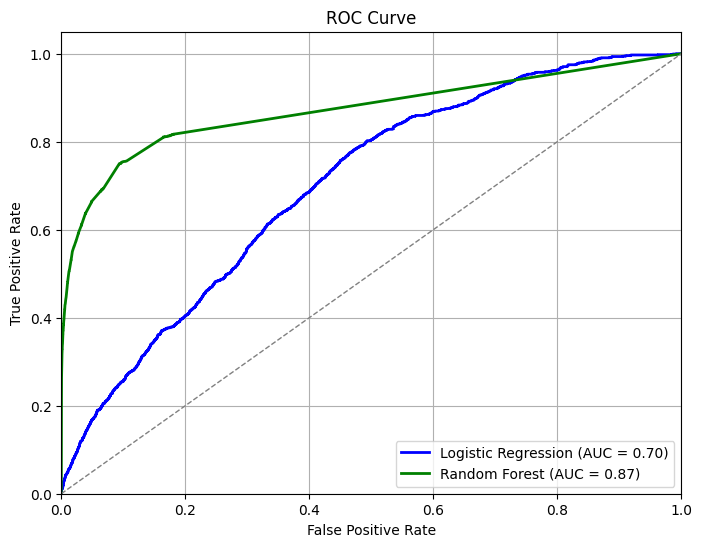

In [11]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Calcolo delle probabilità (necessarie per la ROC)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# ROC curve per entrambi
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, color='blue', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_logreg)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Difatto dalla AUC si deduce quanto la Random Forest funzioni meglio rispetto ad una semplice Regressione Logistica.

# MOD 3: 🚀 XGBoost – Extreme Gradient Boosting

**XGBoost (Extreme Gradient Boosting)** è un algoritmo di apprendimento supervisionato basato su alberi di decisione, progettato per essere **veloce, efficiente** e con alte prestazioni, particolarmente adatto per problemi di classificazione binaria e regressione.

### 🔍 Come funziona?

- XGBoost utilizza la tecnica del **gradient boosting**, che costruisce una sequenza di alberi deboli (solitamente alberi poco profondi).
- Ogni albero successivo corregge gli errori del precedente, minimizzando una funzione di perdita tramite il **metodo del gradiente**.
- Supporta **regolarizzazione** per prevenire overfitting.
- Include ottimizzazioni per la velocità, la gestione di valori nulli, e la gestione dei dati sbilanciati.

### ⚙️ Caratteristiche principali

- Supporta `binary:logistic` come obiettivo per classificazione binaria.
- Permette di usare `scale_pos_weight` per trattare **dataset sbilanciati**.
- Offre **feature importance** per capire quali variabili influenzano di più il modello.



C:\Users\Daniele\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:36:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Classifier ===
[[86157 17416]
 [  340  1057]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    103573
           1       0.06      0.76      0.11      1397

    accuracy                           0.83    104970
   macro avg       0.53      0.79      0.51    104970
weighted avg       0.98      0.83      0.90    104970



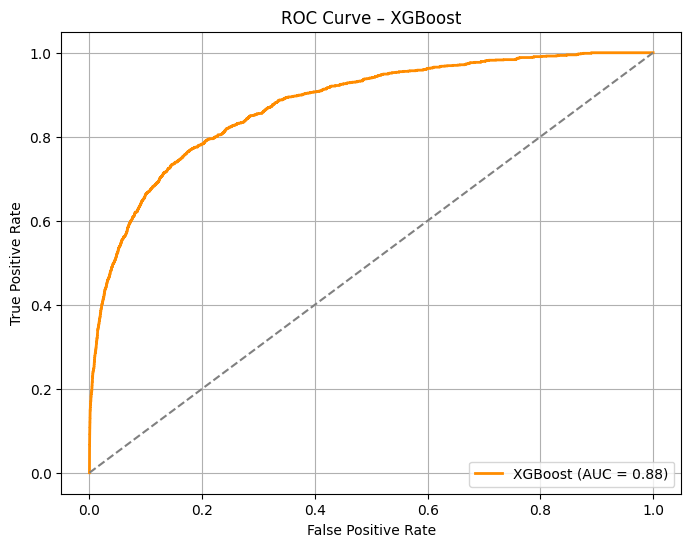

In [13]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Modello
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1])),  # per class imbalance
    random_state=42
)

# Training
xgb_model.fit(X_train, y_train)

# Predizioni
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Valutazione
print("=== XGBoost Classifier ===")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='XGBoost (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
